C:\Users\nikhi\AppData\Local\Temp\ipykernel_12384\75191413.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


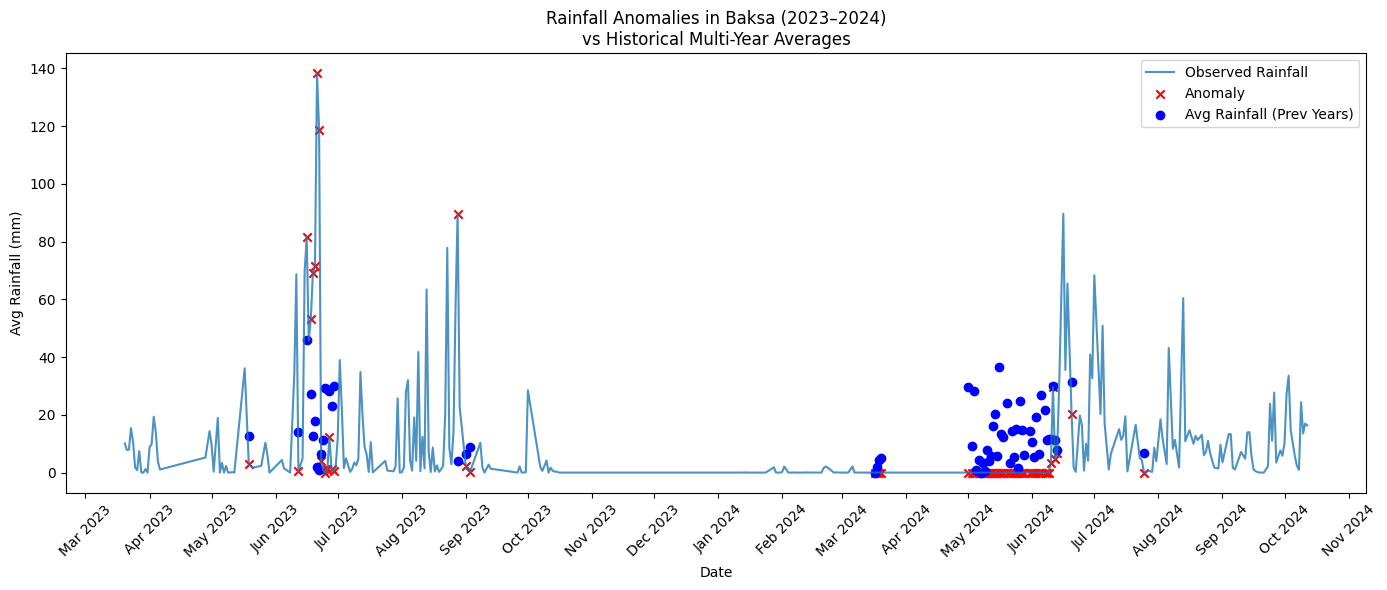

In [3]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    r"C:\Users\nikhi\Desktop\Jupyter Notebook\ML_Rainfall\final_dataset_with_features.csv",
    parse_dates=["Date"]
)

district = "Baksa"
df = df[df['District'] == district].copy()
df.sort_values('Date', inplace=True)

features = [
    'Avg_rainfall', 'Avg_smlvl_at15cm', 'Annual_Temp', 'Temp_Seasonal',
    'Rainfall_lag_1d', 'Rainfall_lag_3d', 'Rainfall_lag_7d',
    'Rainfall_7d_sum', 'Rainfall_7d_avg', 'SoilMoisture_7d_avg',
    'day_of_year', 'week_of_year', 'month_sin', 'month_cos'
]

df.dropna(subset=features, inplace=True)

train_df = df[df['Year'] <= 2022].copy()
test_df = df[df['Year'] >= 2023].copy()

X_train = train_df[features].values
X_test = test_df[features].values

mean_vec = np.mean(X_train, axis=0)
cov_matrix = np.cov(X_train, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

test_df['Mahalanobis_Distance'] = [
    distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_test
]

train_distances = [distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_train]
threshold = np.percentile(train_distances, 95)

test_df['Predicted_Anomaly'] = test_df['Mahalanobis_Distance'] > threshold

anomalies = test_df[test_df['Predicted_Anomaly']].copy()

reference_dates = []
reference_avg_values = []

for _, row in anomalies.iterrows():
    day = row['Date'].day
    month = row['Date'].month
    
    # Historical values on same day/month in prior years
    matched = df[
        (df['Date'].dt.day == day) &
        (df['Date'].dt.month == month) &
        (df['Year'] < row['Year'])  # Only prior years
    ]
    
    if not matched.empty:
        avg_rainfall = matched['Avg_rainfall'].mean()
        reference_dates.append(row['Date'])  # same X-axis point
        reference_avg_values.append(avg_rainfall)

plt.figure(figsize=(14, 6))
plt.plot(test_df['Date'], test_df['Avg_rainfall'], label='Observed Rainfall', alpha=0.8)
plt.scatter(anomalies['Date'], anomalies['Avg_rainfall'], color='red', marker='x', label='Anomaly')

if reference_dates:
    plt.scatter(reference_dates, reference_avg_values, color='blue', marker='o', label='Avg Rainfall (Prev Years)')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.title(f"Rainfall Anomalies in {district} (2023–2024)\nvs Historical Multi-Year Averages")
plt.xlabel("Date")
plt.ylabel("Avg Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()



C:\Users\nikhi\AppData\Local\Temp\ipykernel_12384\2564898402.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


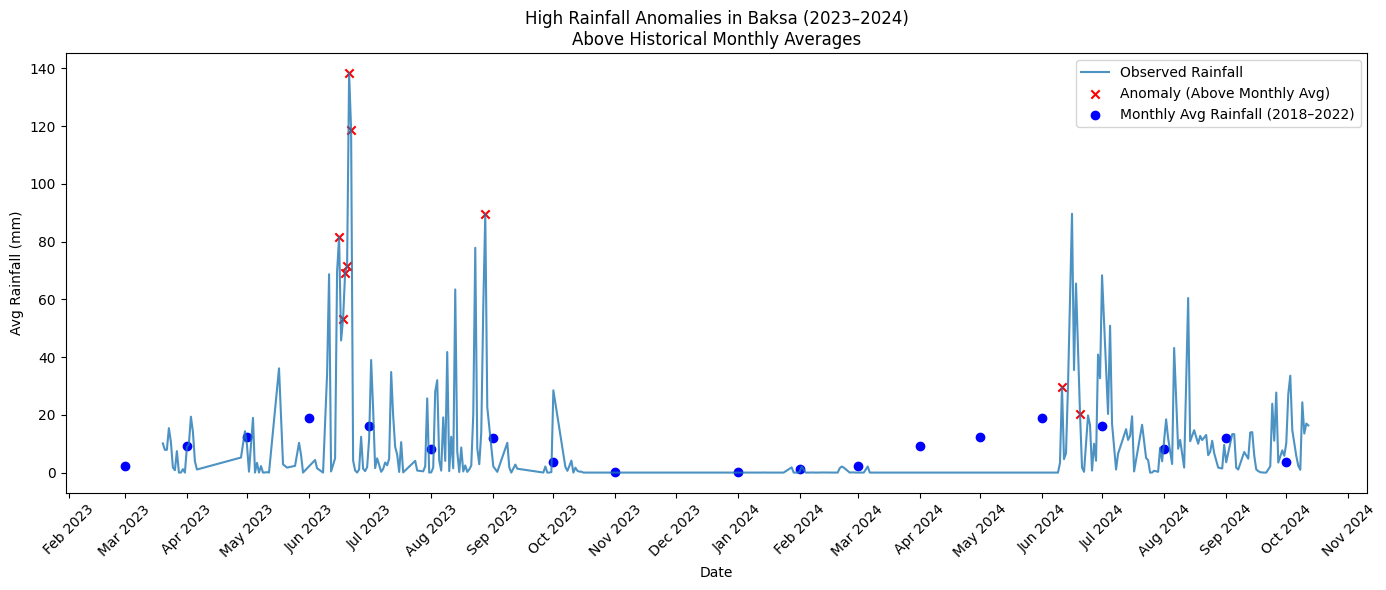

In [5]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    r"C:\Users\nikhi\Desktop\Jupyter Notebook\ML_Rainfall\final_dataset_with_features.csv",
    parse_dates=["Date"]
)

district = "Baksa"
df = df[df['District'] == district].copy()
df.sort_values('Date', inplace=True)

df['Month'] = df['Date'].dt.month

features = [
    'Avg_rainfall', 'Avg_smlvl_at15cm', 'Annual_Temp', 'Temp_Seasonal',
    'Rainfall_lag_1d', 'Rainfall_lag_3d', 'Rainfall_lag_7d',
    'Rainfall_7d_sum', 'Rainfall_7d_avg', 'SoilMoisture_7d_avg',
    'day_of_year', 'week_of_year', 'month_sin', 'month_cos'
]

df.dropna(subset=features, inplace=True)

# Train: 2018–2022 | Test: 2023–2024
train_df = df[df['Year'] <= 2022].copy()
test_df = df[df['Year'] >= 2023].copy()

X_train = train_df[features].values
X_test = test_df[features].values

mean_vec = np.mean(X_train, axis=0)
cov_matrix = np.cov(X_train, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

test_df['Mahalanobis_Distance'] = [
    distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_test
]

train_distances = [distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_train]
threshold = np.percentile(train_distances, 95)

test_df['Predicted_Anomaly'] = test_df['Mahalanobis_Distance'] > threshold

monthly_avg = df[df['Year'] < 2023].groupby('Month')['Avg_rainfall'].mean()

test_df['Monthly_Avg_Rainfall'] = test_df['Month'].map(monthly_avg)

test_df['Above_Monthly_Avg'] = test_df['Avg_rainfall'] > test_df['Monthly_Avg_Rainfall']
filtered_anomalies = test_df[(test_df['Predicted_Anomaly']) & (test_df['Above_Monthly_Avg'])].copy()

monthly_avg_rainfall = test_df[['Date', 'Month']].copy()
monthly_avg_rainfall['Monthly_Avg_Rainfall'] = monthly_avg_rainfall['Month'].map(monthly_avg)
monthly_avg_rainfall['MonthPeriod'] = monthly_avg_rainfall['Date'].dt.to_period('M')
monthly_avg_rainfall = monthly_avg_rainfall.groupby('MonthPeriod').first().reset_index()
monthly_avg_rainfall['Date'] = monthly_avg_rainfall['MonthPeriod'].dt.to_timestamp()
monthly_avg_rainfall.drop(columns=['MonthPeriod'], inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(test_df['Date'], test_df['Avg_rainfall'], label='Observed Rainfall', alpha=0.8)
plt.scatter(filtered_anomalies['Date'], filtered_anomalies['Avg_rainfall'],
            color='red', marker='x', label='Anomaly (Above Monthly Avg)')
plt.scatter(monthly_avg_rainfall['Date'], monthly_avg_rainfall['Monthly_Avg_Rainfall'],
            color='blue', label='Monthly Avg Rainfall (2018–2022)', marker='o')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.title(f"High Rainfall Anomalies in {district} (2023–2024)\nAbove Historical Monthly Averages")
plt.xlabel("Date")
plt.ylabel("Avg Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\nikhi\AppData\Local\Temp\ipykernel_12384\2635724460.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


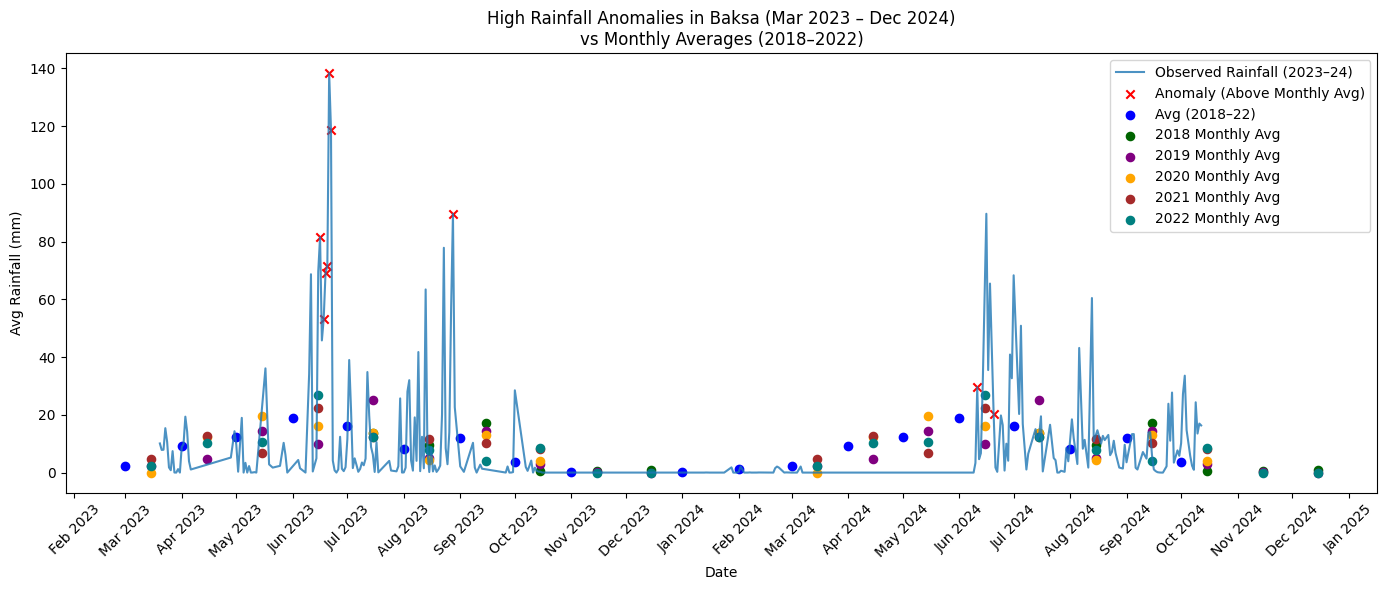

In [6]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    r"C:\Users\nikhi\Desktop\Jupyter Notebook\ML_Rainfall\final_dataset_with_features.csv",
    parse_dates=["Date"]
)

district = "Baksa"
df = df[df['District'] == district].copy()
df.sort_values('Date', inplace=True)

df['Month'] = df['Date'].dt.month

features = [
    'Avg_rainfall', 'Avg_smlvl_at15cm', 'Annual_Temp', 'Temp_Seasonal',
    'Rainfall_lag_1d', 'Rainfall_lag_3d', 'Rainfall_lag_7d',
    'Rainfall_7d_sum', 'Rainfall_7d_avg', 'SoilMoisture_7d_avg',
    'day_of_year', 'week_of_year', 'month_sin', 'month_cos'
]

df.dropna(subset=features, inplace=True)

# Train: 2018–2022 | Test: 2023–2024
train_df = df[df['Year'] <= 2022].copy()
test_df = df[df['Year'] >= 2023].copy()

X_train = train_df[features].values
X_test = test_df[features].values

mean_vec = np.mean(X_train, axis=0)
cov_matrix = np.cov(X_train, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

test_df['Mahalanobis_Distance'] = [
    distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_test
]

train_distances = [distance.mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_train]
threshold = np.percentile(train_distances, 95)

test_df['Predicted_Anomaly'] = test_df['Mahalanobis_Distance'] > threshold

monthly_avg = df[df['Year'] < 2023].groupby('Month')['Avg_rainfall'].mean()
test_df['Monthly_Avg_Rainfall'] = test_df['Month'].map(monthly_avg)

test_df['Above_Monthly_Avg'] = test_df['Avg_rainfall'] > test_df['Monthly_Avg_Rainfall']
filtered_anomalies = test_df[(test_df['Predicted_Anomaly']) & (test_df['Above_Monthly_Avg'])].copy()

monthly_by_year = (
    df[df['Year'].between(2018, 2022)]
    .groupby(['Year', 'Month'])['Avg_rainfall']
    .mean()
    .unstack(level=0) 
)

monthly_by_year = monthly_by_year.loc[3:12]

months = range(3, 13)
plot_dates_2023 = pd.to_datetime([f"2023-{m:02d}-15" for m in months])
plot_dates_2024 = pd.to_datetime([f"2024-{m:02d}-15" for m in months])
all_plot_dates = list(plot_dates_2023) + list(plot_dates_2024)

repeat_monthly = pd.concat([monthly_by_year]*2, ignore_index=True)
repeat_monthly['Date'] = all_plot_dates
repeat_monthly.set_index('Date', inplace=True)

monthly_avg_rainfall = test_df[['Date', 'Month']].copy()
monthly_avg_rainfall['Monthly_Avg_Rainfall'] = monthly_avg_rainfall['Month'].map(monthly_avg)
monthly_avg_rainfall['MonthPeriod'] = monthly_avg_rainfall['Date'].dt.to_period('M')
monthly_avg_rainfall = monthly_avg_rainfall.groupby('MonthPeriod').first().reset_index()
monthly_avg_rainfall['Date'] = monthly_avg_rainfall['MonthPeriod'].dt.to_timestamp()
monthly_avg_rainfall.drop(columns=['MonthPeriod'], inplace=True)

start_date = pd.to_datetime("2023-03-01")
end_date = pd.to_datetime("2024-12-31")
test_df = test_df[(test_df['Date'] >= start_date) & (test_df['Date'] <= end_date)]
filtered_anomalies = filtered_anomalies[(filtered_anomalies['Date'] >= start_date) & (filtered_anomalies['Date'] <= end_date)]
monthly_avg_rainfall = monthly_avg_rainfall[(monthly_avg_rainfall['Date'] >= start_date) & (monthly_avg_rainfall['Date'] <= end_date)]
repeat_monthly = repeat_monthly[(repeat_monthly.index >= start_date) & (repeat_monthly.index <= end_date)]

plt.figure(figsize=(14, 6))

plt.plot(test_df['Date'], test_df['Avg_rainfall'], label='Observed Rainfall (2023–24)', alpha=0.8)
plt.scatter(filtered_anomalies['Date'], filtered_anomalies['Avg_rainfall'],
            color='red', marker='x', label='Anomaly (Above Monthly Avg)')
plt.scatter(monthly_avg_rainfall['Date'], monthly_avg_rainfall['Monthly_Avg_Rainfall'],
            color='blue', label='Avg (2018–22)', marker='o')

colors = ['darkgreen', 'purple', 'orange', 'brown', 'teal']
for i, year in enumerate(range(2018, 2023)):
    plt.scatter(repeat_monthly.index, repeat_monthly[year],
                label=f'{year} Monthly Avg', color=colors[i], marker='o', s=35)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.title(f"High Rainfall Anomalies in {district} (Mar 2023 – Dec 2024)\nvs Monthly Averages (2018–2022)")
plt.xlabel("Date")
plt.ylabel("Avg Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()